Dataset Shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


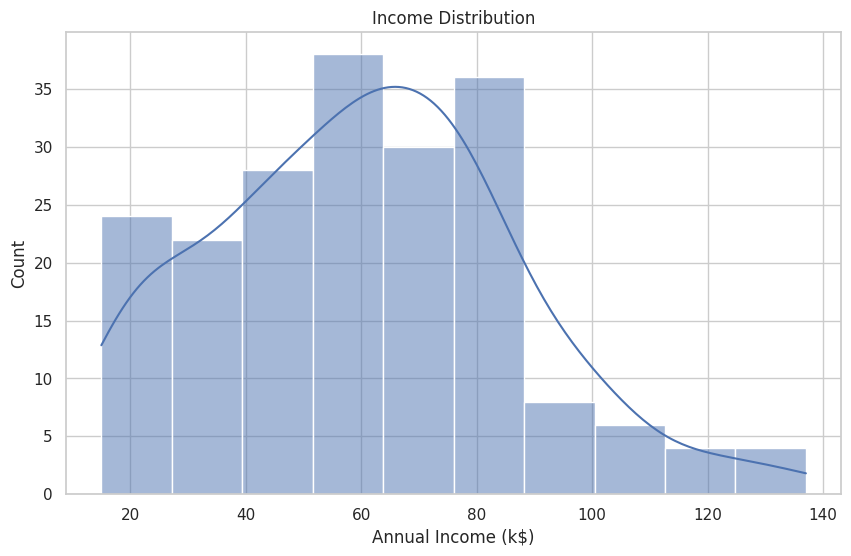

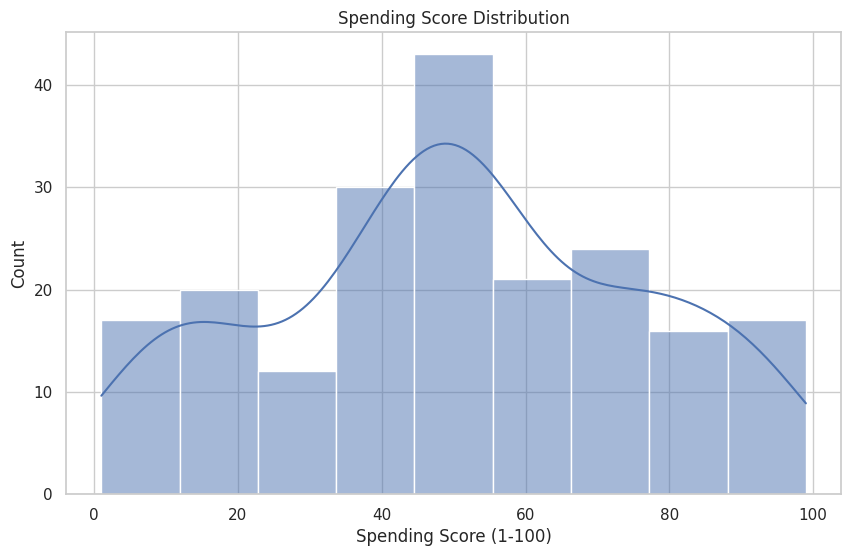

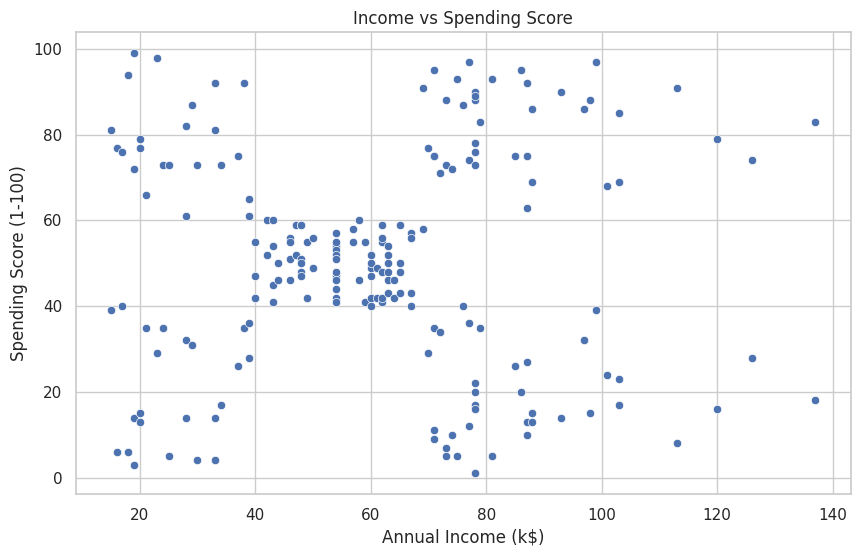

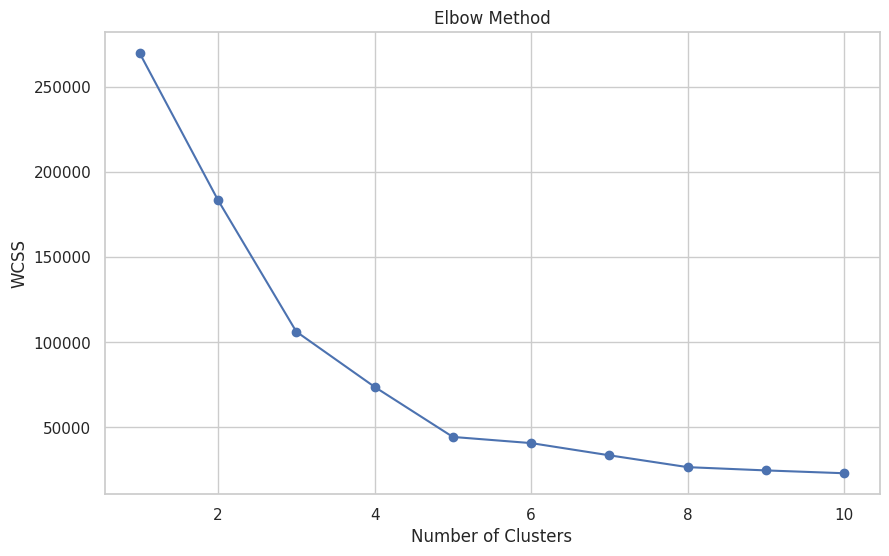

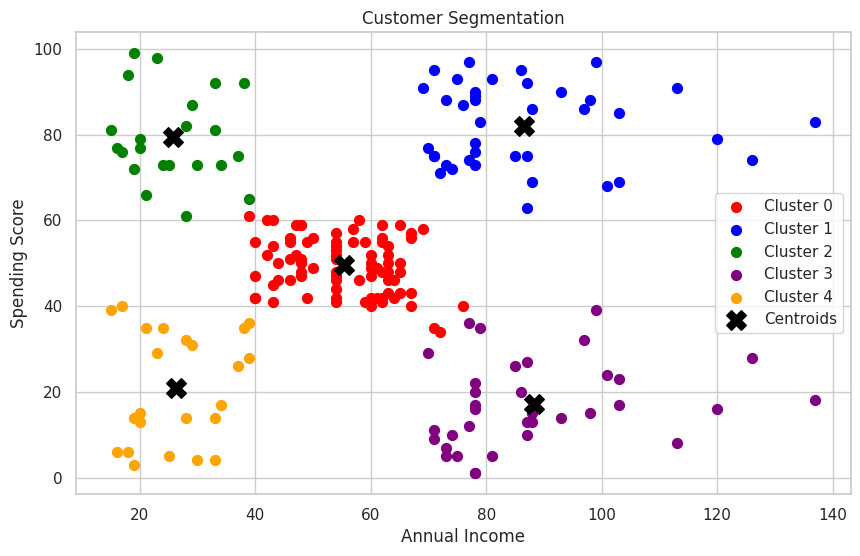


Cluster Centers:
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]

New Customer Details:
Income: 60, Spending Score: 50
Assigned Cluster: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


np.int32(0)

In [2]:
# =========================================================
# Task 02: Customer Segmentation using K-Means Clustering
# Organization: SkillCraft Technology
# Role: Machine Learning Intern
# Objective: Segment customers based on income and spending behavior
# =========================================================

# =========================================================
# 1. Import Libraries
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# =========================================================
# 2. Data Loading & Inspection
# =========================================================
# LOAD YOUR DATASET HERE
df = pd.read_csv("Mall_Customers.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

# =========================================================
# 3. Exploratory Data Analysis (EDA)
# =========================================================

# Distribution plots
plt.figure()
sns.histplot(df['Annual Income (k$)'], kde=True)
plt.title("Income Distribution")
plt.show()

plt.figure()
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.title("Spending Score Distribution")
plt.show()

# Scatter plot
plt.figure()
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)')
plt.title("Income vs Spending Score")
plt.show()

# =========================================================
# 4. Feature Selection
# =========================================================
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# =========================================================
# 5. Elbow Method (Finding Optimal K)
# =========================================================
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# =========================================================
# 6. Model Building & Training
# =========================================================
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

df['Cluster'] = y_kmeans

# =========================================================
# 7. Cluster Visualization
# =========================================================
plt.figure()

colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(5):
    plt.scatter(
        X[y_kmeans == i]['Annual Income (k$)'],
        X[y_kmeans == i]['Spending Score (1-100)'],
        s=50,
        c=colors[i],
        label=f'Cluster {i}'
    )

# Centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

# =========================================================
# 8. Cluster Analysis
# =========================================================
print("\nCluster Centers:")
print(kmeans.cluster_centers_)

# =========================================================
# 9. New Customer Prediction
# =========================================================
def predict_customer(income, score):
    new_data = np.array([[income, score]])
    cluster = kmeans.predict(new_data)[0]

    print("\nNew Customer Details:")
    print(f"Income: {income}, Spending Score: {score}")
    print(f"Assigned Cluster: {cluster}")

    return cluster

# Example
predict_customer(60, 50)